# 6. Base rate neglect

**The mistake in one sentence:** a very accurate test for a very rare thing gives mostly false alarms.

Running on Google Colab? Run the next cell first. It downloads the repo so the data files are there. On your own computer you can skip it.

In [1]:
import os
from pathlib import Path
if not any((p / "src").exists() for p in [Path.cwd(), *Path.cwd().parents]):
    !git clone https://github.com/USERNAME/data-make-sins.git
    os.chdir("data-make-sins/notebooks")

In [2]:
import sys
from pathlib import Path
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.append(str(root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import dms

dms.style()

## The real case

A disease affects 1 person in 1,000. The test is right 99 times out of 100. You test positive. Most people, including many doctors, say you are 99 percent likely to be sick.

In 2017, South Wales Police ran face recognition on the crowd at the Champions League final in Cardiff. The system raised 2,470 alerts. 2,297 were wrong. Only 173 were real matches. Almost nobody in a stadium is on a wanted list, so almost every alert was a false alarm.

## Simulate one million people

In [3]:
rng = np.random.default_rng(3)
n = 1_000_000
prevalence, sensitivity, specificity = 0.001, 0.99, 0.99

sick = rng.random(n) < prevalence
test_positive = np.where(sick, rng.random(n) < sensitivity, rng.random(n) > specificity)
people = pd.DataFrame({"really_sick": sick, "test_positive": test_positive})

table = pd.crosstab(people.really_sick, people.test_positive, rownames=["really sick"], colnames=["test positive"])
table

test positive,False,True
really sick,,
False,989052,9975
True,14,959


In [4]:
tp, fp = table.loc[True, True], table.loc[False, True]
fn, tn = table.loc[True, False], table.loc[False, False]

metrics = pd.Series({
    "accuracy: how often the test is right": (tp + tn) / n,
    "recall: of the sick, how many it finds": tp / (tp + fn),
    "precision: of the positives, how many are real": tp / (tp + fp),
})
(metrics * 100).round(1).astype(str) + " %"

accuracy: how often the test is right             99.0 %
recall: of the sick, how many it finds            98.6 %
precision: of the positives, how many are real     8.8 %
dtype: str

Accuracy 99 percent. Precision 9 percent. Both are true. Only one of them matters to the person holding the positive result.

## Precision depends on how rare the disease is

In [5]:
prev = np.logspace(-4, -0.3, 200)
precision = sensitivity * prev / (sensitivity * prev + (1 - specificity) * (1 - prev))

fig, ax = plt.subplots()
ax.plot(prev * 100, precision * 100, color=dms.BLUE, lw=2.5)
ax.set_xscale("log")
ax.set_xlabel("how common the disease is (% of people), log scale")
ax.set_ylabel("precision (%)")
ax.set_title("The same 99% accurate test, from useless to useful")
for p, label in [(0.001, "1 in 1,000"), (0.01, "1 in 100"), (0.1, "1 in 10")]:
    pr = sensitivity * p / (sensitivity * p + (1 - specificity) * (1 - p))
    ax.scatter([p * 100], [pr * 100], color=dms.RED, zorder=3)
    ax.annotate(f"{label}: precision {pr * 100:.0f}%", (p * 100, pr * 100), (8, -14), textcoords="offset points", fontsize=9)
dms.save(fig, "06_precision_vs_prevalence.png")
plt.show()

## Cardiff, 2017, with the same tools

In [6]:
cardiff = pd.read_csv(dms.DATA / "cardiff_face_recognition_2017.csv", index_col="item")["count"]
print(f"precision = {cardiff['correct']} / {cardiff['alerts']} = {cardiff['correct'] / cardiff['alerts'] * 100:.0f} %")

precision = 173 / 2470 = 7 %


## Animated figure

1,000 people. Red is really sick. Amber is a false alarm.

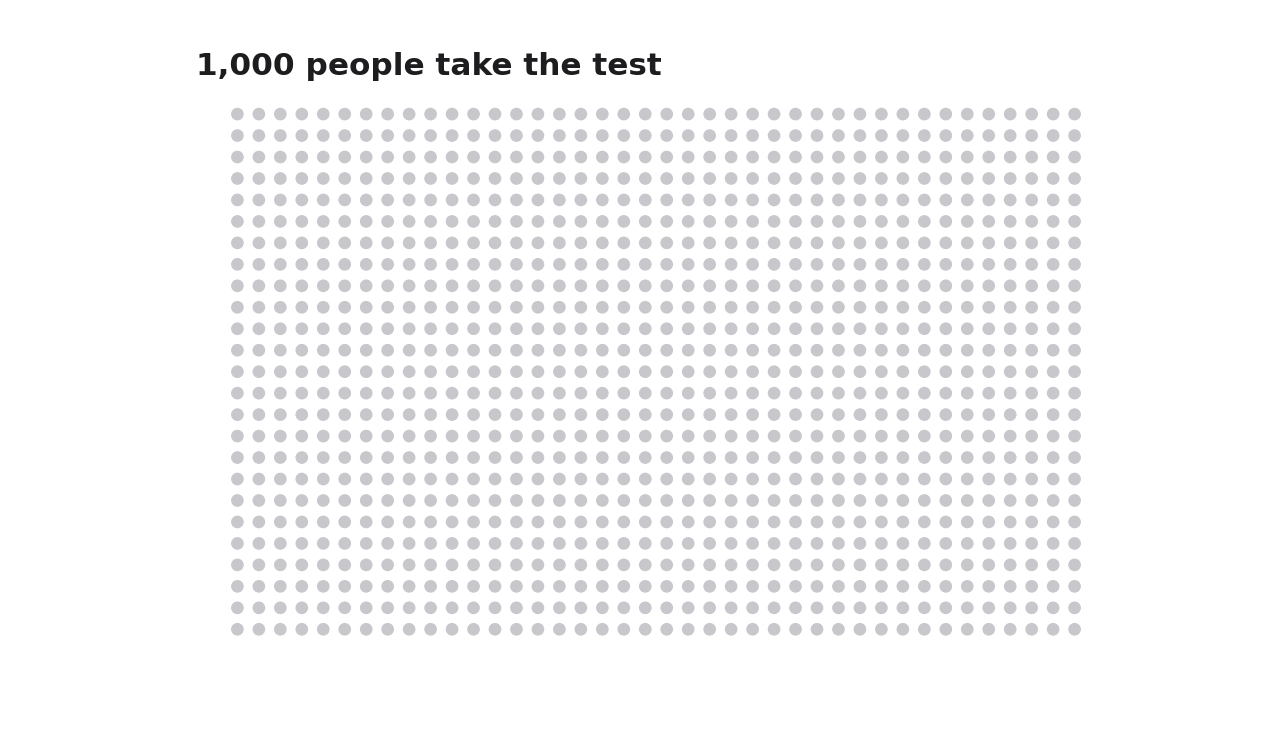

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.6))
n_dots, cols = 1000, 40
xs, ys = np.arange(n_dots) % cols, -(np.arange(n_dots) // cols)
dots = ax.scatter(xs, ys, s=22, c=[dms.GREY] * n_dots)
ax.set_aspect("equal"); ax.axis("off")
title = ax.set_title("")
sick_index = 500
false_alarms = [137, 268, 341, 455, 612, 684, 733, 819, 905, 962]

def update(i):
    colors = np.array([dms.GREY] * n_dots, dtype=object)
    alpha = np.ones(n_dots)
    if i >= 8:
        colors[sick_index] = dms.RED
    if i >= 20:
        for k in false_alarms[: min(10, i - 19)]:
            colors[k] = dms.AMBER
    if i >= 38:
        keep = [sick_index] + false_alarms
        alpha[:] = 0.15; alpha[keep] = 1
    dots.set_color(list(colors)); dots.set_alpha(alpha)
    if i < 8:
        title.set_text("1,000 people take the test")
    elif i < 20:
        title.set_text("1 person is really sick")
    elif i < 32:
        title.set_text("The test is wrong 1 time in 100: about 10 false alarms")
    elif i < 38:
        title.set_text("11 positive results go out")
    else:
        title.set_text("Only 1 of the 11 is real. Precision: 9%")
    return dots, title

anim = FuncAnimation(fig, update, frames=54, interval=150)
gif = dms.FIG / "06_one_in_eleven.gif"
anim.save(gif, writer=PillowWriter(fps=6))
plt.close(fig)
display(Image(filename=str(gif)))

## Better method

Do not ask for accuracy. Ask for two numbers.

- Recall (also called sensitivity): of the people who are really sick, how many does the test find?
- Precision (also called positive predictive value): of the positive results, how many are real?

A confusion matrix, the small table above, shows all four counts at once. Here recall is 99 percent and precision is 9 percent.

## Ask this

How rare was it before the test?